In [ ]:
pip install kagglehub
import pandas as pd
import numpy as np
import os
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt



In [ ]:
dataset_dir = kagglehub.dataset_download('muhammadmusharraf444/loan-approval-dataset')

print(f"Downloaded dataset directory: {dataset_dir}")
print(f"Contents of the directory: {os.listdir(dataset_dir)}")

Using Colab cache for faster access to the 'loan-approval-dataset' dataset.
Downloaded dataset directory: /kaggle/input/loan-approval-dataset
Contents of the directory: ['loan_data_new.csv']


In [ ]:
df = pd.read_csv('/kaggle/input/loan-approval-dataset/loan_data_new.csv')

In [ ]:
df.head()

,Age,Gender,Education,Person Income,Employee Experience,Home Onwership,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1


In [ ]:
df.tail()

,Age,Gender,Education,Person Income,Employee Experience,Home Onwership,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status
44995,27,male,Associate,47971,6,RENT,15000,MEDICAL,15.66,0.31,3,645,No,1
44996,37,female,Associate,65800,17,RENT,9000,HOMEIMPROVEMENT,14.07,0.14,11,621,No,1
44997,33,male,Associate,56942,7,RENT,2771,DEBTCONSOLIDATION,10.02,0.05,10,668,No,1
44998,29,male,Bachelor,33164,4,RENT,12000,EDUCATION,13.23,0.36,6,604,No,1
44999,24,male,High School,51609,1,RENT,6665,DEBTCONSOLIDATION,17.05,0.13,3,628,No,1


In [ ]:
df.shape

(45000, 14)

In [ ]:
df.columns

Index(['Age', 'Gender', 'Education', 'Person Income', 'Employee Experience',
       'Home Onwership', 'Loan Amount', 'Loan Intent', 'Loan interest Rate',
       'Loan percentage', 'Credit History', 'Credit Score', 'Previous Loan',
       'Loan Status'],
      dtype='object')

In [ ]:
df.dtypes

,0
Age,int64
Gender,object
Education,object
Person Income,int64
Employee Experience,int64
Home Onwership,object
Loan Amount,int64
Loan Intent,object
Loan interest Rate,float64
Loan percentage,float64


In [ ]:
type(df.head)

method

In [ ]:
type(df.dtypes)

pandas.core.series.Series

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  45000 non-null  int64  
 1   Gender               45000 non-null  object 
 2   Education            45000 non-null  object 
 3   Person Income        45000 non-null  int64  
 4   Employee Experience  45000 non-null  int64  
 5   Home Onwership       45000 non-null  object 
 6   Loan Amount          45000 non-null  int64  
 7   Loan Intent          45000 non-null  object 
 8   Loan interest Rate   45000 non-null  float64
 9   Loan percentage      45000 non-null  float64
 10  Credit History       45000 non-null  int64  
 11  Credit Score         45000 non-null  int64  
 12  Previous Loan        45000 non-null  object 
 13  Loan Status          45000 non-null  int64  
dtypes: float64(2), int64(7), object(5)
memory usage: 4.8+ MB


In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
Education,0
Person Income,0
Employee Experience,0
Home Onwership,0
Loan Amount,0
Loan Intent,0
Loan interest Rate,0
Loan percentage,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Age,45000.0,27.764178,6.045108,20.00,24.00,26.00,30.00,144.00
Person Income,45000.0,80319.053222,80422.498632,8000.00,47204.00,67048.00,95789.25,7200766.00
Employee Experience,45000.0,5.410333,6.063532,0.00,1.00,4.00,8.00,125.00
Loan Amount,45000.0,9583.157556,6314.886691,500.00,5000.00,8000.00,12237.25,35000.00
Loan interest Rate,45000.0,11.006606,2.978808,5.42,8.59,11.01,12.99,20.00
Loan percentage,45000.0,0.139725,0.087212,0.00,0.07,0.12,0.19,0.66
Credit History,45000.0,5.867489,3.879702,2.00,3.00,4.00,8.00,30.00
Credit Score,45000.0,632.608756,50.435865,390.00,601.00,640.00,670.00,850.00
Loan Status,45000.0,0.222222,0.415744,0.00,0.00,0.00,0.00,1.00


1. Age: As per above information max age 144 which is highly unlikely for a loan applicant to be over 80 or 90 years old. So we have cap any value above 85 at exactly 85.

2. Experience: A person cannot have more years of experience (125) than their actual age. A logical cap is limiting maximum experience to Age - 18 (assuming work starts at 18).

In [ ]:
# Cap Age at 85
df['Age'] = df['Age'].clip(upper=85)

# Cap Experience dynamically based on Age
# If Experience > (Age - 18), replace it with (Age - 18)
df['Employee Experience'] = np.where(
    df['Employee Experience'] > (df['Age'] - 18),
    df['Age'] - 18,
    df['Employee Experience']
)

In [ ]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Age,45000.0,27.757133,5.950182,20.00,24.00,26.00,30.00,85.00
Person Income,45000.0,80319.053222,80422.498632,8000.00,47204.00,67048.00,95789.25,7200766.00
Employee Experience,45000.0,5.403911,5.974078,0.00,1.00,4.00,8.00,67.00
Loan Amount,45000.0,9583.157556,6314.886691,500.00,5000.00,8000.00,12237.25,35000.00
Loan interest Rate,45000.0,11.006606,2.978808,5.42,8.59,11.01,12.99,20.00
Loan percentage,45000.0,0.139725,0.087212,0.00,0.07,0.12,0.19,0.66
Credit History,45000.0,5.867489,3.879702,2.00,3.00,4.00,8.00,30.00
Credit Score,45000.0,632.608756,50.435865,390.00,601.00,640.00,670.00,850.00
Loan Status,45000.0,0.222222,0.415744,0.00,0.00,0.00,0.00,1.00


1. Person Income is 7200766 which highly gap between the average earners and the millionaires so applying a log transformation compresses. It pulls the extreme right tail back toward the center, turning a highly skewed curve into a more normal, bell-shaped distribution.

2. Implemented log transformations to normalize highly right-skewed financial distributions, improving model stability across diverse income brackets.

In [ ]:
df['Person Income_log'] = np.log1p(df['Person Income'])

In [ ]:
# Suppress scientific notation and show 3 decimal places
pd.set_option('display.float_format', '{:.3f}'.format)

In [ ]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Age,45000.000,27.757,5.950,20.000,24.000,26.000,30.000,85.000
Person Income,45000.000,80319.053,80422.499,8000.000,47204.000,67048.000,95789.250,7200766.000
Employee Experience,45000.000,5.404,5.974,0.000,1.000,4.000,8.000,67.000
Loan Amount,45000.000,9583.158,6314.887,500.000,5000.000,8000.000,12237.250,35000.000
Loan interest Rate,45000.000,11.007,2.979,5.420,8.590,11.010,12.990,20.000
Loan percentage,45000.000,0.140,0.087,0.000,0.070,0.120,0.190,0.660
Credit History,45000.000,5.867,3.880,2.000,3.000,4.000,8.000,30.000
Credit Score,45000.000,632.609,50.436,390.000,601.000,640.000,670.000,850.000
Loan Status,45000.000,0.222,0.416,0.000,0.000,0.000,0.000,1.000
Person Income_log,45000.000,11.122,0.558,8.987,10.762,11.113,11.470,15.790


In [ ]:
# Drop the original skewed column
df = df.drop(columns=['Person Income'])

In [ ]:
df['Gender'].unique().tolist()

['female', 'male']

1. Handling Nominal Data: Converting a "Gender" column into numerical data, as there is no mathematical ranking or order between genders.

2. Using Binary Mapping (Best if there are only 2 categories)
If your dataset strictly contains two categories (e.g., "Male" and "Female"), the cleanest and most efficient approach is a direct binary map. This turns it into a simple 0 or 1.

Note: A Decision Tree does not care which one is 0 and which one is 1; it just looks for the mathematical split.

In [ ]:
# Create a mapping dictionary
gender_mapping = {
    'Male': 0,
    'Female': 1
}

# Apply the mapping
df['Gender'] = df['Gender'].map(gender_mapping)

In [ ]:
df['Education'].unique().tolist()

['Master', 'High School', 'Bachelor', 'Associate', 'Doctorate']

Ordinal Data (Clear, ranked order)

1. If the categories have a strict hierarchy—for example, an Education column with values like "High School", "Bachelor", "Master"—you should use Ordinal Encoding or mapping.

2. This assigns a progressive number to each level, preserving the ranking so the Decision Tree understands that a Master's degree is "higher" than High School.

How to implement it:
You can manually map these values using a dictionary to ensure the order is exactly right.

In [ ]:
# Create a mapping dictionary
education_mapping = {
    'High School': 0,
    "Bachelor": 1,
    "Master": 2,
    "Associate": 3,
    "Doctorate": 4
}

# Apply the mapping to the column
df['Education_Level'] = df['Education'].map(education_mapping)

In [ ]:
df.columns

Index(['Age', 'Gender', 'Education', 'Employee Experience', 'Home Onwership',
       'Loan Amount', 'Loan Intent', 'Loan interest Rate', 'Loan percentage',
       'Credit History', 'Credit Score', 'Previous Loan', 'Loan Status',
       'Person Income_log', 'Education_Level'],
      dtype='object')

One-Hot Encoding (Best if there are 3+ categories)
1. If your dataset includes multiple categories (e.g., "Rent", "Own", "Other", "Mortgage"), you should absolutely use One-Hot Encoding. If you try to map these as 0, 1, 2, and 3, the model might mistakenly think that category 3 is mathematically "greater" than category 1.

2. One-Hot Encoding solves this by creating a separate binary column for each category.

3. If you had "Rent", "Own", "Other", "Mortgage", using drop_first=True means the model will create a Home Onwership_OTHER column (0 or 1) and a Home Onwership_OWN column (0 or 1). If both are 0, the model mathematically deduces the person.

In [ ]:
df['Home Onwership'].unique().tolist()

['RENT', 'OWN', 'MORTGAGE', 'OTHER']

In [ ]:
df['Loan Intent'].unique().tolist()

['PERSONAL',
 'EDUCATION',
 'MEDICAL',
 'VENTURE',
 'HOMEIMPROVEMENT',
 'DEBTCONSOLIDATION']

In [ ]:
df = pd.get_dummies(df, columns=['Home Onwership', 'Loan Intent'], drop_first=True)

In [ ]:
df.columns

Index(['Age', 'Gender', 'Education', 'Employee Experience', 'Loan Amount',
       'Loan interest Rate', 'Loan percentage', 'Credit History',
       'Credit Score', 'Previous Loan', 'Loan Status', 'Person Income_log',
       'Education_Level', 'Previous_loan', 'Home Onwership_OTHER',
       'Home Onwership_OWN', 'Home Onwership_RENT', 'Loan Intent_EDUCATION',
       'Loan Intent_HOMEIMPROVEMENT', 'Loan Intent_MEDICAL',
       'Loan Intent_PERSONAL', 'Loan Intent_VENTURE'],
      dtype='object')

In [ ]:
df['Home Onwership_OTHER'].unique().tolist()

[False, True]

In [ ]:
df['Previous Loan'].unique().tolist()

['No', 'Yes']

In [ ]:
# Create a mapping dictionary
previous_loan_mapping = {
    'No': 0,
    'Yes': 1
}

# Apply the mapping
df['Previous_loan'] = df['Previous Loan'].map(previous_loan_mapping)

In [ ]:
df = df.drop(columns=['Education', 'Previous Loan'])

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Separate the features (X) and the target (y)
# Drop the target column from X
X = df.drop(columns=['Loan Status'])
# Set y to only the target column
y = df['Loan Status']

# 2. Split the data into Training and Testing sets
# test_size=0.2 means 20% of data is used for testing
# random_state ensures you get the exact same random split every time you run the code
# Earlier, we saw that only 22% of the people in your dataset defaulted on their loans, while 78% paid them off safely. This is called an imbalanced dataset.

# If you randomly shuffle and split the data, pure bad luck could result in a Training Set that is 95% safe loans and only 5% defaults. Your model would barely learn what a default looks like!

# Adding stratify=y forces Scikit-Learn to maintain that exact 78/22 ratio in both your Training Set and your Testing Set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (36000, 19)
Testing data shape: (9000, 19)


1. When you run dt_model.fit(), we need to look at how a Decision Tree measures "goodness."

2. When a Decision Tree looks at your data, it has one primary goal: Create groups that are as "pure" as possible. A perfectly "pure" group is one where every single person has the exact same Loan Status (e.g., a group of 100 people who all safely paid off their loans, or a group of 50 people who all defaulted).

3. The Math Behind the Split: Gini Impurity
To measure this purity, the algorithm uses a mathematical formula called Gini Impurity. It scores a group from 0 to 0.5:

4. Gini = 0.0: Perfect purity (everyone in the group has the exact same Loan Status).

5. Gini = 0.5: Maximum impurity (the group is exactly a 50/50 split of safe loans and defaults).

Here is exactly what the algorithm does behind the scenes during .fit():

1. It looks at a single feature, like Credit Score.

2. It tests every single possible number as a splitting point (e.g., "What if I split the data at Credit Score < 500? What about < 501? What about < 502?").

3. For every test, it calculates the Gini Impurity of the two new groups it just created.

4. It officially chooses the split that results in the lowest possible Gini Impurity (the purest groups).

5. It repeats this process for Income, Age, and Experience, growing the tree deeper and deeper until the groups are as pure as possible.

6. Here is a visual representation of how that mathematical split works. Try adjusting the threshold to find the "purest" split!

In [ ]:
# 1. Initialize the model
# (random_state ensures the tree builds the exact same way every time)
dt_model = DecisionTreeClassifier(random_state=42)

# 2. Train the model using the training data
dt_model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


Model Accuracy: 90.13%

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.94      7000
           1       0.77      0.79      0.78      2000

    accuracy                           0.90      9000
   macro avg       0.86      0.86      0.86      9000
weighted avg       0.90      0.90      0.90      9000



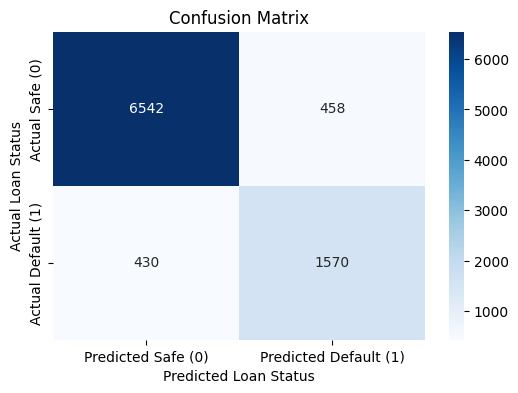

In [ ]:
# 1. Ask the model to predict the outcomes for the testing data
y_pred = dt_model.predict(X_test)

# 2. Calculate the overall Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

# 3. Generate a Classification Report (shows Precision, Recall, and F1-Score)
print("Classification Report:")
print(classification_report(y_test, y_pred))

# 4. Create and visualize the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Safe (0)', 'Predicted Default (1)'],
            yticklabels=['Actual Safe (0)', 'Actual Default (1)'])
plt.ylabel('Actual Loan Status')
plt.xlabel('Predicted Loan Status')
plt.title('Confusion Matrix')
plt.show()

Accuracy is a great starting point, but in risk modeling, the Confusion Matrix is what businesses actually care about. When the matrix generates, you will see four squares:

True Negatives (Top Left): The model correctly predicted a safe loan. (Good!)

True Positives (Bottom Right): The model correctly predicted a default. (Good!)

False Positives (Top Right): The model predicted a default, but the person was actually safe. (The bank loses a potential customer).

False Negatives (Bottom Left): The model predicted a safe loan, but the person actually defaulted! (This is the most dangerous and expensive mistake for a bank).

1. The Confusion Matrix (The Business Reality)
The matrix shows us exactly where the model succeeded and where it made mistakes on your 9,000 test cases.

True Negatives (6,542 - Top Left): The model correctly predicted these people would safely pay off their loans. (Good for business!)

True Positives (1,570 - Bottom Right): The model correctly predicted these people would default. (You saved the bank from giving out bad loans!)

False Positives (458 - Top Right): The model predicted a default, but the person was actually safe. (The bank lost out on the interest revenue from 458 good customers because the model was too strict).

False Negatives (430 - Bottom Left): The model predicted they were safe, but they actually defaulted. (This is the most dangerous number. The bank actively lost money on these 430 people).

2. The Classification Report (Precision vs. Recall)
Because the bank cares most about catching defaults (Class 1), look closely at the row for 1 in your classification report:

Recall (0.79): Out of all the people who actually defaulted (2,000 total), your model successfully caught 79% of them.

Precision (0.77): When your model flags someone as a default risk, it is correct 77% of the time.

Top 3 Most Important Features:
               Feature  Importance
10       Previous_loan       0.294
4   Loan interest Rate       0.163
5      Loan percentage       0.156

----------------------------------------



/tmp/ipykernel_1617/1098555364.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


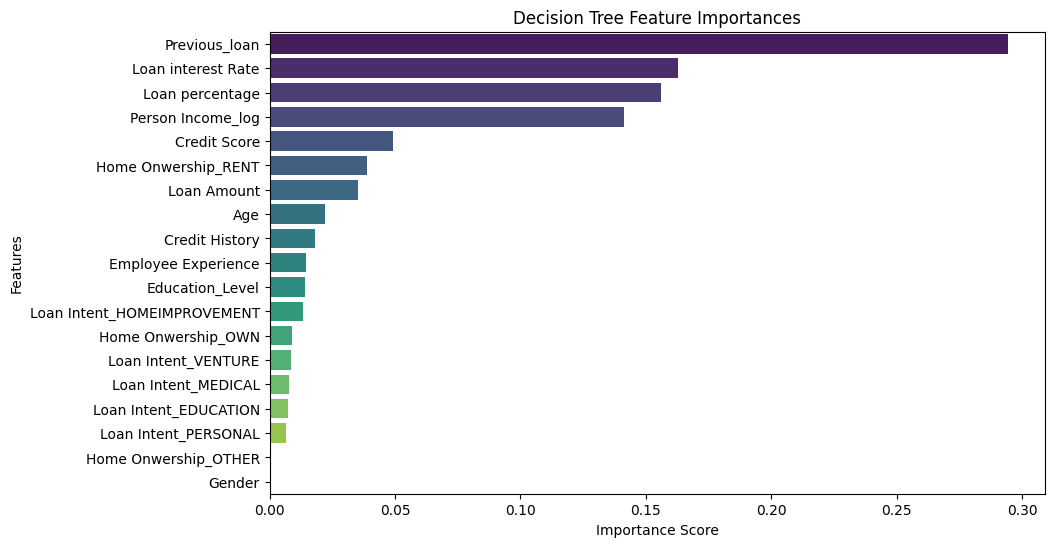

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract the raw importance numbers from the trained model
importances = dt_model.feature_importances_

# 2. Get the exact column names from your training data
feature_names = X_train.columns

# 3. Combine them into a Pandas DataFrame for easy sorting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# 4. Sort the dataframe from highest importance to lowest
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# 5. Print the top 3 features
print("Top 3 Most Important Features:")
print(importance_df.head(3))
print("\n" + "-"*40 + "\n")

# 6. Visualize all the features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Decision Tree Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

The #1 Predictor is Past Behavior (Previous_loan - 29.4%): The single most important factor determining if someone will default is whether they have had a previous loan. This makes perfect logical sense in finance—past credit behavior is the ultimate indicator of future risk.

The Loan Mechanics Matter (Interest Rate & Percentage): The 2nd and 3rd most important features are the Loan interest Rate and Loan percentage (likely debt-to-income ratio). This tells the bank that high interest rates might actually be causing people to default because the payments become too burdensome.

Ethical AI (Gender - 0.0): Look at the very bottom of your chart. The Gender column has practically zero importance. This is actually a massive win for your model! It proves that your algorithm is fair and is not penalizing applicants based on their gender.